# 03 · Feature Engineering — Favorita

Basiert auf den EDA-Erkenntnissen aus Notebook 02:

| Feature-Gruppe | Begründung |
|---|---|
| Lags 1, 7, 14, 21, 28 | ACF-Analyse: Wochenmultiplikatoren dominieren (ACF 7 ≈ 0.76) |
| Rolling Mean 7, 14, 28 Tage | Trendschätzung auf wöchentlicher/monatlicher Ebene |
| Wochentag + Monat (zyklisch) | Starke Wochen- und leichte Monatssaisonalität |
| Ölpreis (interpoliert + MA7) | Exogener Regressor, Ecuador ölabhängig |
| Feiertags-Features | +13% Tag vor, +12% am Tag selbst, +11% Tag danach |
| Store-Typ + Cluster | Erklärt Level-Unterschiede zwischen Stores |

**Aufbau:** Sektionen 1–7 erklären jede Funktion einzeln an Store 1. Sektion 8 baut den finalen Datensatz über alle Stores in einer sauberen Pipeline.

In [1]:
import sys
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append(os.path.abspath('../03_src'))
from feature import (
    add_lag, add_rolling_mean, add_momentum_features,
    add_cyclical_time_features, add_historical_benchmarks,
    add_ratio_features, add_difference_features,
    add_oil_features, add_holiday_features, add_store_features,
)

sns.set_style('whitegrid')
PROCESSED = Path('..') / '02_data' / 'processed'

In [2]:
tx     = pl.read_parquet(PROCESSED / 'transactions.parquet')
stores = pl.read_parquet(PROCESSED / 'stores.parquet')
oil    = pl.read_parquet(PROCESSED / 'oil.parquet')
hol    = pl.read_parquet(PROCESSED / 'holidays.parquet')

# Store 1 als Beispiel für Sektionen 1–7
# (hat eine der vollständigsten Zeitreihen)
sample = tx.filter(pl.col('store_nbr') == 1).sort('date')

print('Alle Stores:', tx.shape)
print('Beispiel Store 1:', sample.shape)

Alle Stores: (83488, 3)
Beispiel Store 1: (1676, 3)


## 1 · Lag-Features

Lags 7, 14, 21, 28 (ACF > 0.68) + Lag 1. Berechnung `.over('store_nbr')` — jede Serie bleibt für sich.

In [3]:
demo = add_lag(sample, lags=[1, 7, 14, 21, 28], group_col='store_nbr')

print('Neue Spalten:', [c for c in demo.columns if c.startswith('lag_')])
# head(35).tail(10) zeigt Zeilen 26–35 — erste NaNs sind schon aufgelöst
demo.select(['date', 'transactions', 'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28']).head(35).tail(10)

Neue Spalten: ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28']


date,transactions,lag_1,lag_7,lag_14,lag_21,lag_28
date,i64,i64,i64,i64,i64,i64
2013-01-27,542,1295,507,542,520,null
2013-01-28,1738,542,1770,1780,1807,null
2013-01-29,1772,1738,1762,1680,1869,null
2013-01-30,1877,1772,1873,1933,1910,2111
2013-01-31,1707,1877,1616,1786,1679,1833
2013-02-01,1806,1707,1770,1745,1813,1863
2013-02-02,1377,1806,1295,1389,1473,1509
2013-02-03,531,1377,542,507,542,520
2013-02-04,1714,531,1738,1770,1780,1807


## 2 · Rolling Mean

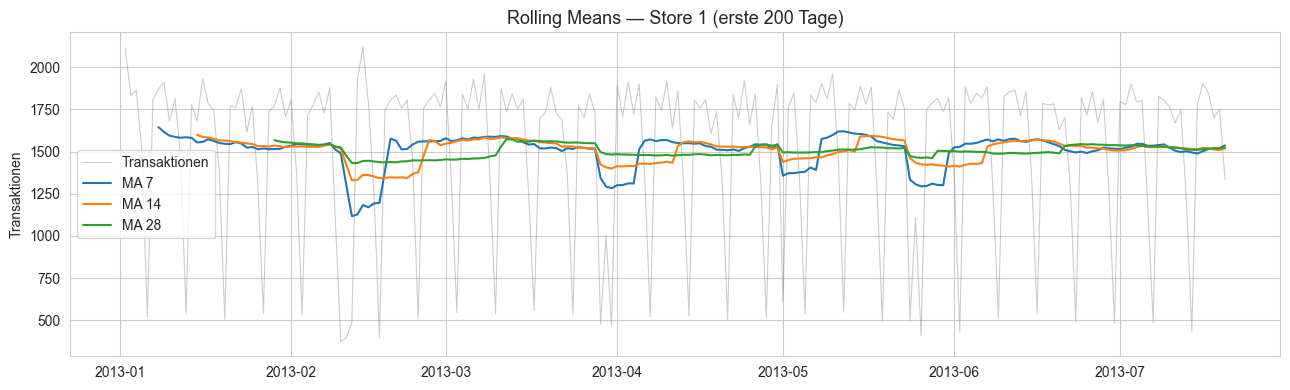

In [4]:
demo = add_rolling_mean(demo, window_sizes=[7, 14, 28], group_col='store_nbr')

demo_pd = demo.to_pandas().head(200)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(demo_pd['date'], demo_pd['transactions'],
        alpha=0.4, linewidth=0.8, color='gray', label='Transaktionen')
ax.plot(demo_pd['date'], demo_pd['rolling_mean_7_days'],  linewidth=1.5, label='MA 7')
ax.plot(demo_pd['date'], demo_pd['rolling_mean_14_days'], linewidth=1.5, label='MA 14')
ax.plot(demo_pd['date'], demo_pd['rolling_mean_28_days'], linewidth=1.5, label='MA 28')
ax.set_title('Rolling Means — Store 1 (erste 200 Tage)', fontsize=13)
ax.set_ylabel('Transaktionen')
ax.legend()
plt.tight_layout()
plt.show()

## 3 · Momentum, Benchmarks, Ratio & Differenz

In [5]:
demo = add_momentum_features(demo, over='store_nbr')
demo = add_historical_benchmarks(demo, over_cols=['store_nbr'])
demo = add_ratio_features(demo)
demo = add_difference_features(demo)

new_cols = (
    [c for c in demo.columns if 'growth' in c] +
    [c for c in demo.columns if 'weekday' in c or 'weeks' in c] +
    [c for c in demo.columns if 'vs' in c] +
    [c for c in demo.columns if c.startswith('diff_')]
)
print('Neue Features:')
for c in new_cols:
    print(f'  {c}')

Neue Features:
  wow_growth
  mom_growth
  same_weekday_last_week
  same_weekday_4weeks_ago
  sales_vs_week_avg
  wow_vs_month_avg
  diff_1
  diff_7
  diff_28


## 4 · Zyklische Zeit-Features

Neu gegenüber altem Projekt: **Wochentag** zyklisch encodiert — bei täglichen Daten entscheidend.

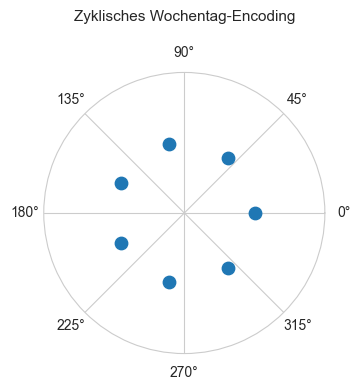

In [6]:
demo = add_cyclical_time_features(demo)

theta = np.linspace(0, 2 * np.pi, 7, endpoint=False)
labels = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']

fig, ax = plt.subplots(figsize=(4, 4), subplot_kw={'projection': 'polar'})
ax.scatter(theta, [1] * 7, s=80, zorder=5)
for t, l in zip(theta, labels):
    ax.annotate(l, (t, 1.18), ha='center', fontsize=10)
ax.set_yticks([])
ax.set_title('Zyklisches Wochentag-Encoding', pad=18, fontsize=11)
plt.tight_layout()
plt.show()

## 5 · Ölpreis-Features

529 von 1704 Tagen haben keinen Börsenkurs (Wochenenden, Feiertage, max. 4 aufeinanderfolgende Tage). `forward_fill` ist ausreichend.

Oil NaN vor fill: 43 von 1218
Oil NaN nach fill: 0


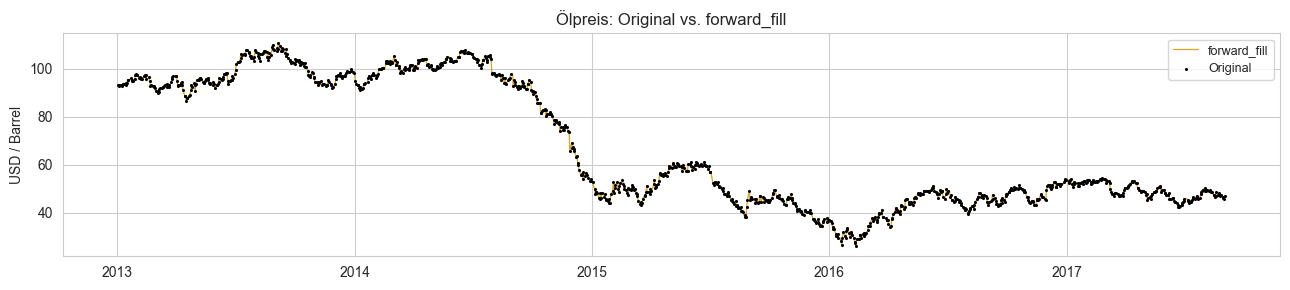

In [7]:
print('Oil NaN vor fill:', oil['dcoilwtico'].null_count(), 'von', len(oil))

demo = add_oil_features(demo, oil)

print('Oil NaN nach fill:', demo['oil_price'].null_count())

oil_filled = (
    oil.sort('date')
    .with_columns(pl.col('dcoilwtico').forward_fill().alias('oil_filled'))
    .to_pandas()
)
oil_pd = oil.sort('date').to_pandas()

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(oil_filled['date'], oil_filled['oil_filled'],
        linewidth=0.9, color='goldenrod', label='forward_fill')
ax.scatter(oil_pd['date'], oil_pd['dcoilwtico'],
           s=1.5, color='black', zorder=5, label='Original')
ax.set_title('Ölpreis: Original vs. forward_fill', fontsize=12)
ax.set_ylabel('USD / Barrel')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Feiertags-Features

`transferred=True` Einträge werden herausgefiltert — verschobene Feiertage sind am ursprünglichen Datum **kein** Feiertag mehr.

In [8]:
demo = add_holiday_features(demo, hol)

print('Feiertags-Features:')
for c in ['is_national_holiday', 'is_day_before_holiday',
          'is_day_after_holiday', 'is_holiday_window', 'hol_type_national']:
    print(f'  {c}')

print()
demo.filter(
    pl.col('is_national_holiday') | pl.col('is_holiday_window')
).select(['date', 'transactions', 'is_national_holiday',
          'is_day_before_holiday', 'is_day_after_holiday', 'hol_type_national']).head(12)

Feiertags-Features:
  is_national_holiday
  is_day_before_holiday
  is_day_after_holiday
  is_holiday_window
  hol_type_national



date,transactions,is_national_holiday,is_day_before_holiday,is_day_after_holiday,hol_type_national
date,i64,bool,bool,bool,str
2013-01-02,2111,false,false,true,"""none"""
2013-01-04,1863,false,true,false,"""none"""
2013-01-05,1509,true,false,false,"""Work Day"""
2013-01-06,520,false,false,true,"""none"""
2013-01-11,1813,false,true,false,"""none"""
…,…,…,…,…,…
2013-02-10,374,false,true,false,"""none"""
2013-02-11,396,true,true,false,"""Holiday"""
2013-02-12,487,true,false,true,"""Holiday"""


## 7 · Store-Features

In [9]:
demo = add_store_features(demo, stores)

print('store_type_enc: A=5, B=4, C=3, D=2, E=1')
demo.select(['store_nbr', 'store_type_enc', 'cluster']).unique().sort('store_nbr')

store_type_enc: A=5, B=4, C=3, D=2, E=1


store_nbr,store_type_enc,cluster
i64,i8,i64
1,2,13


---
## 8 · Komplette Pipeline → final_dataset.parquet

Die Sektionen 1–7 haben jede Funktion einzeln auf Store 1 erklärt.
Hier läuft die Pipeline einmal sauber über **alle 54 Stores**.

Reihenfolge:
```
sort → store_features → time_features → lag → rolling_mean
     → momentum → benchmarks → ratio → difference
     → oil → holidays
```
`momentum` und `benchmarks` brauchen `lag_7` / `lag_28`, deshalb nach `add_lag`.
`ratio` braucht `rolling_mean_7/28` und `lag_7`, deshalb nach beiden.
`oil` und `holidays` joinen nur auf `date` — reihenfolgeunabhängig.

In [10]:
df_final = (
    tx
    .sort(['store_nbr', 'date'])
    .pipe(add_store_features,        stores)
    .pipe(add_cyclical_time_features)
    .pipe(add_lag,                   lags=[1, 7, 14, 21, 28])
    .pipe(add_rolling_mean,          window_sizes=[7, 14, 28])
    .pipe(add_momentum_features)
    .pipe(add_historical_benchmarks)
    .pipe(add_ratio_features)
    .pipe(add_difference_features)
    .pipe(add_oil_features,          oil)
    .pipe(add_holiday_features,      hol)
)

print(f'Shape nach Pipeline: {df_final.shape}')

Shape nach Pipeline: (83695, 37)


In [11]:
# Warm-up-Period entfernen: erste 28 Tage pro Store (= max Lag)
df_final = (
    df_final
    .with_columns(
        pl.col('date').rank().over('store_nbr').alias('_day_rank')
    )
    .filter(pl.col('_day_rank') > 28)
    .drop('_day_rank')
)

print(f'Shape nach Warm-up Drop: {df_final.shape}')
print(f'(Entfernt: 28 Tage × 54 Stores = {28 * 54} Zeilen)')

Shape nach Warm-up Drop: (82183, 37)
(Entfernt: 28 Tage × 54 Stores = 1512 Zeilen)


In [12]:
# Sanity-Check
nan_total = df_final.null_count().sum_horizontal().sum()
assert nan_total == 0, f'Unerwartete NaN-Werte: {nan_total}'

print('✓ Keine NaN-Werte')
print(f'Shape:    {df_final.shape}')
print(f'Zeitraum: {df_final["date"].min()} → {df_final["date"].max()}')
print(f'Stores:   {df_final["store_nbr"].n_unique()}')
print(f'Features: {len(df_final.columns) - 2} (ohne date, store_nbr)')
print()
print('Alle Spalten:')
for col in df_final.columns:
    print(f'  {col:<38} {df_final[col].dtype}')

✓ Keine NaN-Werte
Shape:    (82183, 37)
Zeitraum: 2013-01-29 → 2017-08-15
Stores:   54
Features: 35 (ohne date, store_nbr)

Alle Spalten:
  date                                   Date
  store_nbr                              Int64
  transactions                           Int64
  store_type_enc                         Int8
  cluster                                Int64
  month                                  Int8
  weekday                                Int8
  quarter                                Int8
  weekday_sin                            Float64
  weekday_cos                            Float64
  month_sin                              Float64
  month_cos                              Float64
  lag_1                                  Int64
  lag_7                                  Int64
  lag_14                                 Int64
  lag_21                                 Int64
  lag_28                                 Int64
  rolling_mean_7_days                    Float64
  rolling_m

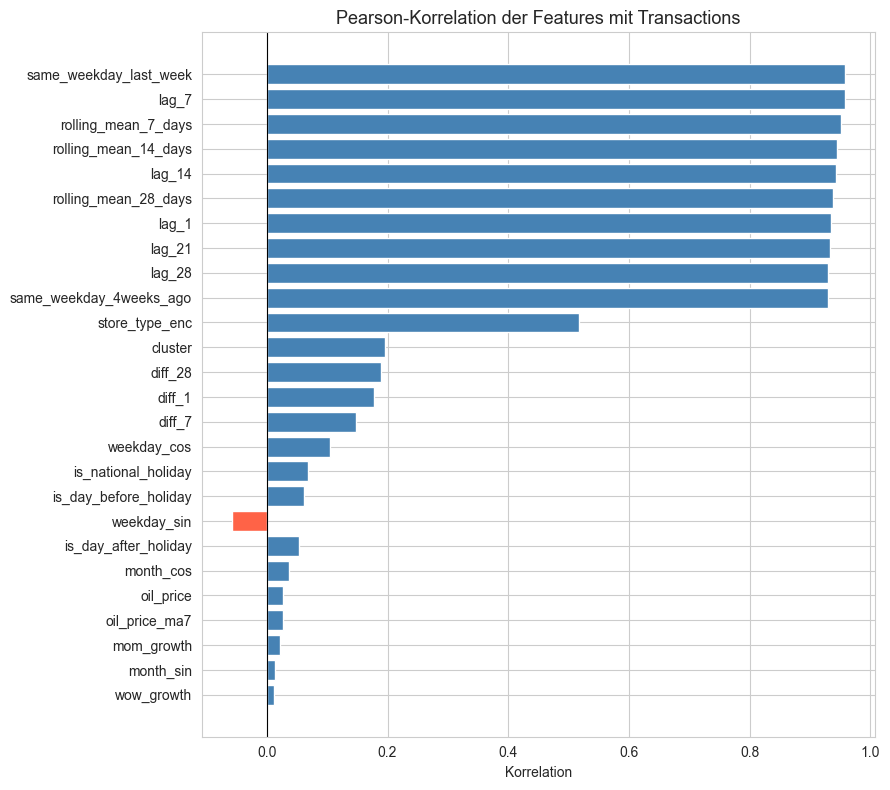

In [15]:
# Feature-Korrelationen mit Target
numeric_cols = [
    'lag_1', 'lag_7', 'lag_14', 'lag_21', 'lag_28',
    'rolling_mean_7_days', 'rolling_mean_14_days', 'rolling_mean_28_days',
    'wow_growth', 'mom_growth',
    'same_weekday_last_week', 'same_weekday_4weeks_ago',
    'diff_1', 'diff_7', 'diff_28',
    'oil_price', 'oil_price_ma7',
    'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
    'store_type_enc', 'cluster',
    'is_national_holiday', 'is_day_before_holiday', 'is_day_after_holiday',
]

corr = (
    df_final
    .select(['transactions'] + numeric_cols)
    .cast({pl.Boolean: pl.Int8})
    .to_pandas()
    .corr()['transactions']
    .drop('transactions')
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['steelblue' if v >= 0 else 'tomato' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson-Korrelation der Features mit Transactions', fontsize=13)
ax.set_xlabel('Korrelation')
plt.tight_layout()
plt.show()

In [16]:
FINAL = Path('..') / '02_data' / 'final'
FINAL.mkdir(parents=True, exist_ok=True)

df_final.write_parquet(FINAL / 'final_dataset.parquet')
print('Gespeichert: final_dataset.parquet')

Gespeichert: final_dataset.parquet
